<a href="https://colab.research.google.com/github/Parv-01/Kshitij_Sir_Repo_Check_IITP/blob/main/RL_Emo_Per_executability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RL-Emo-Per: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/RL-Emo-Per](https://github.com/Mishrakshitij/RL-Emo-Per)
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'RL-Emo-Per'
COMMIT = '2127d849a6a0ce9990d8cbcc6179c47115c2f30b'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: 2127d849a6a0ce9990d8cbcc6179c47115c2f30b
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


### Compatibility with the repository requirements
The table checks installed versions against the base dependencies and optional dependency groups used by this experiment.

In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,"torch>=2.2,<3",2.13.0+cu129,True
1,"transformers>=4.45,<6",4.57.6,True
2,"nltk>=3.9,<4",3.10.3,True
3,"numpy>=1.24,<3",2.3.5,True
4,"matplotlib>=3.7,<4",3.10.7,True


PASS: Python and all dependencies declared for the tested paths are compatible.


# RL-Emo-Per: a five-update executability study
This notebook follows the released pipeline: train the emotion and persuasion
reward heads, fit both speaker language models, perform one sequence-PPO
update, reload the saved policy, and evaluate four held-out persuader responses.
Each of the five stages performs one optimizer update. Tiny downloaded models
check the implementation; generated text and scores are not research results.

In [ ]:
import csv
import json
import math
import os
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

REPO_ROOT, OUTPUT_DIR = Path(REPO_ROOT), Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO_ROOT / "src"))
torch.set_num_threads(2)
COMMIT = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True).strip()
print({"repository": "Mishrakshitij/RL-Emo-Per", "commit": COMMIT,
       "torch": torch.__version__, "device": DEVICE})

{'repository': 'Mishrakshitij/RL-Emo-Per', 'commit': '2127d849a6a0ce9990d8cbcc6179c47115c2f30b', 'torch': '2.13.0+cu129', 'device': 'cuda'}


## Dataset verification and analysis
The repository verifier checks hashes, labels, split statistics and dialogue
separation. Empty emotion/strategy labels are expected on persuadee turns:
only persuader responses carry those targets.

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,dialogues,utterances,persuader_utterances
train,346,7108,3596
validation,39,798,402


,dialogue_id,speaker,text,emotion,strategy
0,20180825-042845_49_live,persuader,"Hello, are you interested in protection of rig...",caring,source-related-inquiry
1,20180825-042845_49_live,persuadee,"Yes, definitely. What do you have in mind?",NaN,NaN
2,20180825-042845_49_live,persuader,There is organisation called Save the Children...,caring,credibility-appeal
3,20180825-042845_49_live,persuadee,"Is this the same group where people used to ""s...",NaN,NaN


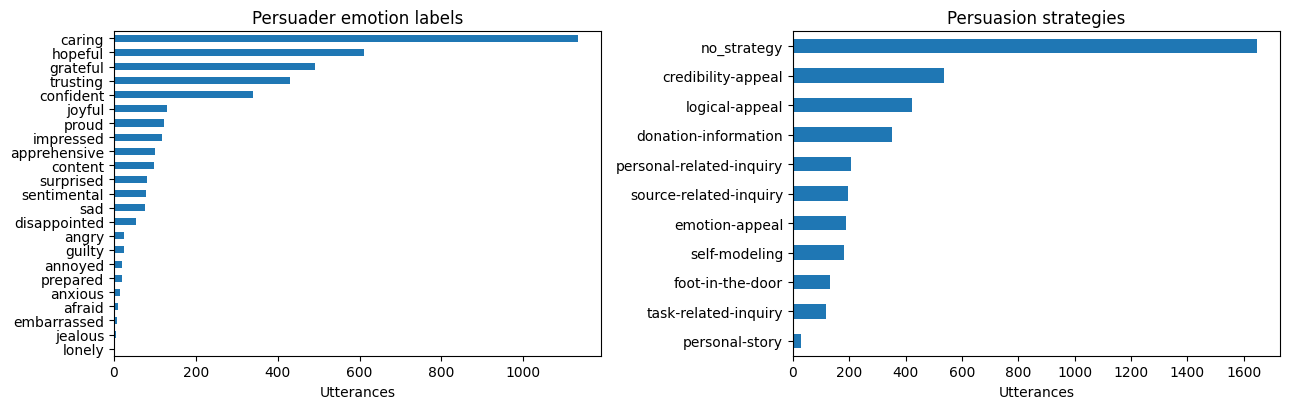

{'dialogues': 385, 'utterances': 7906, 'persuader_targets': 3998, 'integrity_check': 'passed'}


In [ ]:
from rl_emo_per.data import FIELDS, dataset_summary, dialogue_examples, load_records, verify_dataset
from rl_emo_per.generation import evaluate_language_model, generate_response
from rl_emo_per.training import train_classifier, train_mle, train_rl
from rl_emo_per.rewards import _meteor_backend

verification = verify_dataset(REPO_ROOT / "datasets")
records = load_records(REPO_ROOT / "datasets/dialogues.csv")
summary = dataset_summary(records)
display(pd.DataFrame(summary["splits"]).T)
display(pd.DataFrame(records)[["dialogue_id", "speaker", "text", "emotion", "strategy"]].head(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
pd.Series(summary["emotion_counts"]).sort_values().plot.barh(ax=axes[0], title="Persuader emotion labels")
pd.Series(summary["strategy_counts"]).sort_values().plot.barh(ax=axes[1], title="Persuasion strategies")
for axis in axes:
    axis.set_xlabel("Utterances")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_analysis.png", dpi=150)
plt.show()
print({"dialogues": summary["dialogues"], "utterances": summary["utterances"],
       "persuader_targets": summary["persuader_utterances"], "integrity_check": "passed"})

## A small, dialogue-disjoint subset
Four complete round pairs are retained from one training dialogue and one
distinct validation dialogue. Keeping chronological prefixes preserves real
preceding context. Each split has four persuader and four persuadee targets.

In [ ]:
def small_prefix(path):
    rows = load_records(path)
    for dialogue_id in sorted({row["dialogue_id"] for row in rows}):
        dialogue = [row for row in rows if row["dialogue_id"] == dialogue_id]
        shared_turns = sorted(set(row["turn_id"] for row in dialogue if row["speaker"] == "persuader") &
                              set(row["turn_id"] for row in dialogue if row["speaker"] == "persuadee"))
        if len(shared_turns) >= 4:
            selected_turns = set(shared_turns[:4])
            selected = [row for row in dialogue if row["turn_id"] in selected_turns]
            if Counter(row["speaker"] for row in selected) == {"persuader": 4, "persuadee": 4}:
                return selected
    raise ValueError("No dialogue prefix with four paired rounds is available")

subset_paths = {}
subsets = {}
for split in ("train", "validation"):
    rows = small_prefix(REPO_ROOT / "datasets" / f"{split}.csv")
    destination = OUTPUT_DIR / f"{split}_subset.csv"
    with destination.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=FIELDS)
        writer.writeheader()
        writer.writerows(rows)
    subsets[split], subset_paths[split] = rows, destination
assert {row["dialogue_id"] for row in subsets["train"]}.isdisjoint(
    {row["dialogue_id"] for row in subsets["validation"]})
display(pd.DataFrame([{ "split": split, "rows": len(rows),
                       "persuader_targets": len(dialogue_examples(rows)),
                       "persuadee_targets": len(dialogue_examples(rows, speaker="persuadee"))}
                      for split, rows in subsets.items()]))

,split,rows,persuader_targets,persuadee_targets
0,train,8,4,4
1,validation,8,4,4


## Reward resources and native classifier training
NLTK WordNet is required by the repository's METEOR reward implementation.
Missing resources are downloaded explicitly. Two tiny RoBERTa classifiers
retain the full 23-emotion and 11-strategy class vocabularies, with newly
initialized task heads. Each classifier performs one update.

In [ ]:
import nltk
if os.environ.get("HF_HOME"):
    prepared_nltk = Path(os.environ["HF_HOME"]).parent / "nltk"
    if prepared_nltk.is_dir():
        nltk.data.path.insert(0, str(prepared_nltk))
try:
    _meteor_backend()
except RuntimeError:
    resource_dir = OUTPUT_DIR / "nltk_data"
    resource_dir.mkdir(exist_ok=True)
    nltk.data.path.insert(0, str(resource_dir))
    assert nltk.download("wordnet", download_dir=str(resource_dir), quiet=True)
    _meteor_backend()

common = {"train_path": subset_paths["train"], "validation_path": subset_paths["validation"],
          "epochs": 1, "batch_size": 2, "max_length": 48,
          "max_steps": 1, "seed": 42, "device": DEVICE}
stage_results = {}
for task in ("emotion", "strategy"):
    stage_results[task] = train_classifier(
        **common, output_dir=OUTPUT_DIR / task, task=task,
        model_name=str(ENCODER_MODEL), learning_rate=1e-4)
    assert stage_results[task]["steps"] == 1
    assert stage_results[task]["best"]["validation"]["examples"] == 4
    assert math.isfinite(stage_results[task]["best"]["training_loss"])
display(pd.DataFrame({task: stage_results[task]["best"]["validation"]
                      for task in ("emotion", "strategy")}).T)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at hf-internal-testing/tiny-random-roberta and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 32]) in the checkpoint and torch.Size([23, 32]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([23]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at hf-internal-testing/tiny-random-roberta and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([2, 32]) in the checkpoint and torch.Size([11, 32]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([11]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,loss,accuracy,macro_f1,examples
emotion,3.138097,0.0,0.0,4.0
strategy,2.398709,0.0,0.0,4.0


## Native speaker-specific maximum-likelihood training
Both speaker roles start from a downloaded tiny GPT-2 checkpoint. Native
response masks restrict the objective to response tokens. Each model is
trained for one update and saved with its tokenizer and training metadata.

In [ ]:
for speaker in ("persuader", "persuadee"):
    stage_results[speaker] = train_mle(
        **common, output_dir=OUTPUT_DIR / f"mle_{speaker}", speaker=speaker,
        model_name=str(CAUSAL_MODEL), learning_rate=1e-4, warmup_steps=0)
    assert stage_results[speaker]["steps"] == 1
    assert stage_results[speaker]["best"]["validation"]["examples"] == 4
    assert math.isfinite(stage_results[speaker]["best"]["validation"]["nll"])
display(pd.DataFrame({speaker: stage_results[speaker]["best"]["validation"]
                      for speaker in ("persuader", "persuadee")}).T)

,nll,perplexity,response_tokens,examples
persuader,10.818522,49937.238574,118.0,4.0
persuadee,10.821362,50079.271922,68.0,4.0


## Native sequence-PPO update
The saved persuader initializes the policy; the two saved classifiers supply
emotion and persuasion rewards. The repository combines these with repetition
and NLTK METEOR rewards. One rollout batch and one PPO epoch add exactly one
optimizer update, bringing the project total to five.

In [ ]:
stage_results["rl"] = train_rl(
    **common, output_dir=OUTPUT_DIR / "rl_policy",
    model_name=str(OUTPUT_DIR / "mle_persuader"),
    emotion_model=str(OUTPUT_DIR / "emotion"), strategy_model=str(OUTPUT_DIR / "strategy"),
    learning_rate=1e-4, max_new_tokens=4, num_candidates=1, ppo_epochs=1)
assert stage_results["rl"]["steps"] == stage_results["rl"]["optimizer_steps"] == 1
assert math.isfinite(stage_results["rl"]["best"]["rollout"]["policy_loss"])
total_updates = sum(stage_results[name]["steps"] for name in ("emotion", "strategy", "persuader", "persuadee")) + stage_results["rl"]["optimizer_steps"]
assert total_updates == 5
display(pd.DataFrame([stage_results["rl"]["best"]["rollout"]]))
print({"total_optimizer_updates": total_updates})

,policy_loss,reward,clip_fraction,approx_kl,actions
0,-2.980232e-08,4.270199,0.0,0.000051,4.0


{'total_optimizer_updates': 5}


## Reload, evaluate and inspect four responses
The public evaluation and generation functions each load the saved policy.
Evaluation measures response-token NLL and perplexity on the four validation
persuader responses. Generation is bounded to eight new tokens per context.

In [ ]:
metrics = evaluate_language_model(subset_paths["validation"], OUTPUT_DIR / "rl_policy",
                                  speaker="persuader", batch_size=2, max_length=48, device=DEVICE)
assert metrics["examples"] == 4 and math.isfinite(metrics["nll"]) and math.isfinite(metrics["perplexity"])
predictions = []
for index, example in enumerate(dialogue_examples(subsets["validation"])):
    responses = generate_response(OUTPUT_DIR / "rl_policy", example["prompt"],
                                  max_length=48, max_new_tokens=8, seed=42 + index, device=DEVICE)
    assert len(responses) == 1
    predictions.append({"dialogue_id": example["dialogue_id"], "turn_id": example["turn_id"],
                        "reference": example["text"], "generated_response": responses[0]})
display(pd.DataFrame(predictions))
display(pd.DataFrame([metrics]))
checkpoints = ["emotion", "strategy", "mle_persuader", "mle_persuadee", "rl_policy"]
for directory in checkpoints:
    path = OUTPUT_DIR / directory
    assert (path / "config.json").is_file()
    assert any(path.glob("*.safetensors")) or (path / "pytorch_model.bin").is_file()
(OUTPUT_DIR / "predictions.json").write_text(json.dumps(predictions, indent=2))
result = {"project": "RL-Emo-Per", "repository": "https://github.com/Mishrakshitij/RL-Emo-Per.git",
          "commit": COMMIT, "status": "pass", "optimizer_updates": total_updates, "eval_samples": 4,
          "counts": {"released_utterances": len(records), "train_rows": 8, "validation_rows": 8,
                     "train_targets_per_speaker": 4, "evaluation": 4},
          "model": {"causal_lm": str(CAUSAL_MODEL), "reward_encoder": str(ENCODER_MODEL)},
          "metrics": metrics, "stages": stage_results, "checkpoints": checkpoints,
          "checks": {"dataset_integrity": True, "dialogue_disjoint": True, "classifier_training": True,
                     "both_speaker_mle": True, "native_ppo": True, "save_reload": True, "heldout_evaluation": True},
          "limitations": ["One update per stage verifies execution, not convergence or reported benchmark quality.",
                          "Tiny downloaded model fixtures and newly initialized reward heads replace the paper-scale backbones.",
                          "Four examples per speaker do not cover all emotion and persuasion classes.",
                          "The native RL implementation uses the persuader policy and two classifiers; the separately saved persuadee model is not consumed by that API."]}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False))
print({"status": "pass", "optimizer_updates": total_updates, "evaluated_examples": 4})

,dialogue_id,turn_id,reference,generated_response
0,20180825-042845_49_live,0,"Hello, are you interested in protection of rig...",perennlingtonProsigning protagonist receive Pe...
1,20180825-042845_49_live,1,There is organisation called Save the Children...,DAV discord billboard Craig terrain overallsam...
2,20180825-042845_49_live,2,"Here is their website, URL They help children...",earliestailand turmoil territ forgetting Qing ...
3,20180825-042845_49_live,3,"As you mentioned,this organisation has differe...",Cf Crafting522 Haku shooters Control altogethe...


,nll,perplexity,response_tokens,examples
0,10.818607,49941.475663,118,4


{'status': 'pass', 'optimizer_updates': 5, 'evaluated_examples': 4}


## Project summary

**Result: PASS for the tested smoke configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **4 held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.